In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

In [3]:
df = pd.read_csv("dataset_03_employee_attrition.csv")

df.head()

,age,monthly_income,years_at_company,job_satisfaction,overtime_hours,promotion_years,target
0,18,554.86,2.69,1,8.30,1.22,1
1,60,104.33,5.99,4,1.00,7.71,1
2,36,205.49,0.82,2,7.03,2.80,0
3,25,372.61,0.00,3,9.18,0.00,1
4,43,228.28,8.66,7,14.67,5.11,0


In [4]:
df.shape

(1000, 7)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               1000 non-null   int64  
 1   monthly_income    1000 non-null   float64
 2   years_at_company  1000 non-null   float64
 3   job_satisfaction  1000 non-null   int64  
 4   overtime_hours    1000 non-null   float64
 5   promotion_years   1000 non-null   float64
 6   target            1000 non-null   int64  
dtypes: float64(4), int64(3)
memory usage: 54.8 KB


In [6]:
df.describe()

,age,monthly_income,years_at_company,job_satisfaction,overtime_hours,promotion_years,target
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,41.234000,194.321590,5.251560,3.026000,10.525500,4.945410,0.50000
std,13.809633,177.698433,3.595384,1.753967,7.072481,3.571468,0.50025
min,18.000000,17.980000,0.000000,0.000000,1.000000,0.000000,0.00000
25%,29.000000,94.537500,2.507500,2.000000,4.847500,2.147500,0.00000
50%,41.000000,146.130000,5.070000,3.000000,9.500000,4.650000,0.50000
75%,53.000000,232.142500,7.715000,4.000000,15.302500,7.372500,1.00000
max,65.000000,2161.230000,20.690000,10.000000,31.960000,16.500000,1.00000


In [7]:
df.isnull().sum()

,0
age,0
monthly_income,0
years_at_company,0
job_satisfaction,0
overtime_hours,0
promotion_years,0
target,0


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df["target"].value_counts()

,count
target,
1,500
0,500


In [10]:
df["target"].value_counts(normalize=True) * 100

,proportion
target,
1,50.0
0,50.0


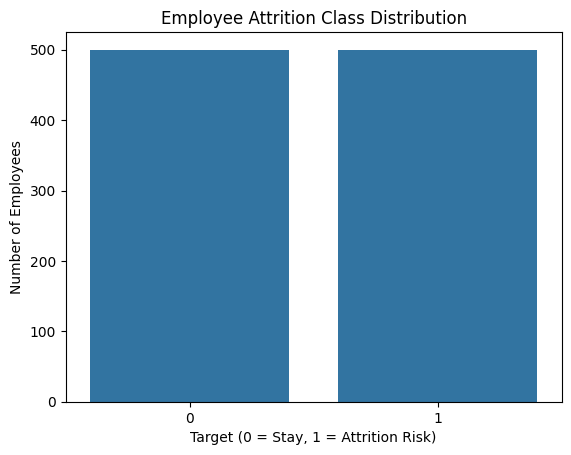

In [11]:
sns.countplot(x="target", data=df)
plt.title("Employee Attrition Class Distribution")
plt.xlabel("Target (0 = Stay, 1 = Attrition Risk)")
plt.ylabel("Number of Employees")
plt.show()

In [12]:
df.describe()

,age,monthly_income,years_at_company,job_satisfaction,overtime_hours,promotion_years,target
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,41.234000,194.321590,5.251560,3.026000,10.525500,4.945410,0.50000
std,13.809633,177.698433,3.595384,1.753967,7.072481,3.571468,0.50025
min,18.000000,17.980000,0.000000,0.000000,1.000000,0.000000,0.00000
25%,29.000000,94.537500,2.507500,2.000000,4.847500,2.147500,0.00000
50%,41.000000,146.130000,5.070000,3.000000,9.500000,4.650000,0.50000
75%,53.000000,232.142500,7.715000,4.000000,15.302500,7.372500,1.00000
max,65.000000,2161.230000,20.690000,10.000000,31.960000,16.500000,1.00000


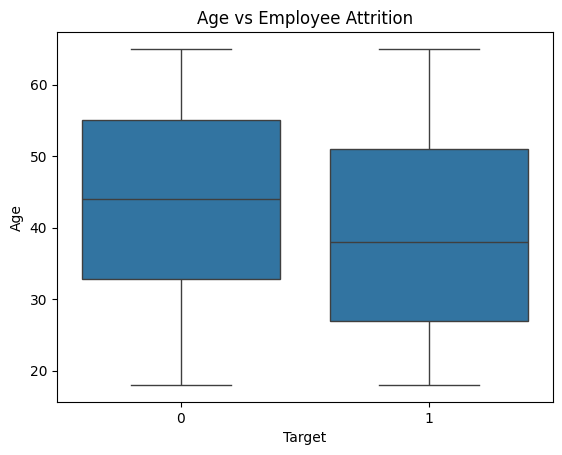

In [13]:
sns.boxplot(x="target", y="age", data=df)
plt.title("Age vs Employee Attrition")
plt.xlabel("Target")
plt.ylabel("Age")
plt.show()

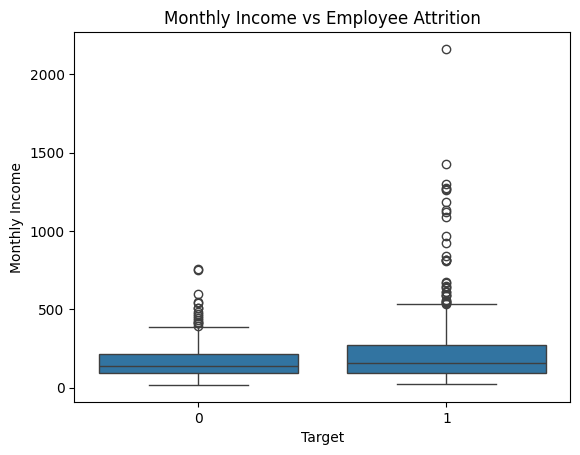

In [14]:
sns.boxplot(x="target", y="monthly_income", data=df)
plt.title("Monthly Income vs Employee Attrition")
plt.xlabel("Target")
plt.ylabel("Monthly Income")
plt.show()

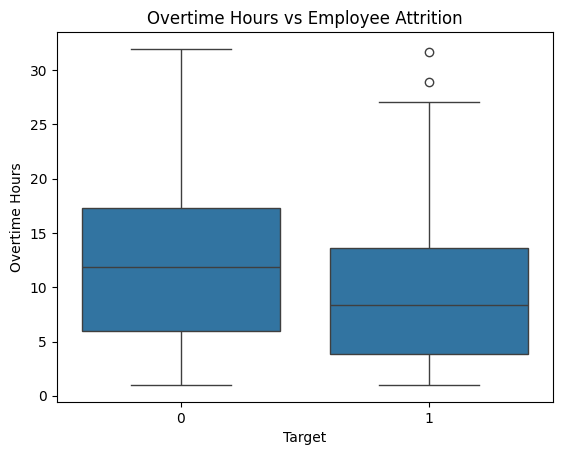

In [15]:
sns.boxplot(x="target", y="overtime_hours", data=df)
plt.title("Overtime Hours vs Employee Attrition")
plt.xlabel("Target")
plt.ylabel("Overtime Hours")
plt.show()

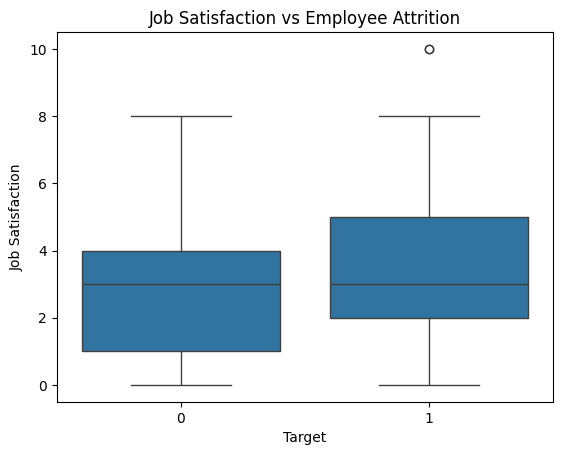

In [16]:
sns.boxplot(x="target", y="job_satisfaction", data=df)
plt.title("Job Satisfaction vs Employee Attrition")
plt.xlabel("Target")
plt.ylabel("Job Satisfaction")
plt.show()

In [17]:
X = df.drop("target", axis=1)

In [18]:
y = df["target"]

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [20]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [21]:
scaler.fit_transform(X_train)

array([[ 1.71689768,  1.62985874,  1.30261305,  1.12005501, -1.36025511,
         0.66669024],
       [-0.0825025 , -0.51020742, -0.32092738, -1.146976  ,  1.37981094,
         0.48275227],
       [ 0.8531856 ,  3.65084632, -0.16983648,  0.55329726,  0.05265735,
        -1.36794666],
       ...,
       [-0.0825025 , -0.67170079, -0.69178687,  1.12005501, -0.76697246,
        -0.22753127],
       [ 0.27737754, -0.31405378, -0.4802596 ,  0.55329726, -0.5729606 ,
        -1.36794666],
       [ 0.70923358,  1.67162731, -1.21923148, -0.58021825, -1.07345497,
        -0.94630425]])

In [22]:
scaler.transform(X_test)

array([[-1.52202264, -0.6302847 ,  0.58012382, -0.0134605 , -1.36025511,
        -1.36794666],
       [ 0.99713761, -0.76628221, -1.42526453, -1.146976  , -0.05981329,
         0.52236968],
       [ 0.78120959,  0.18305676, -0.87859017, -0.0134605 , -0.18774865,
        -0.68030165],
       ...,
       [ 0.70923358, -0.38660537, -1.05165793, -0.0134605 ,  1.32779327,
         2.2938338 ],
       [-1.52202264, -0.11132057,  0.4207916 ,  1.12005501,  0.67686942,
        -0.09735978],
       [ 0.78120959, -0.3114102 ,  0.72297341,  0.55329726,  1.28842854,
         1.14492895]])

In [23]:
model = LogisticRegression(random_state=42)

model.fit(X_train_scaled, y_train)

LogisticRegression(random_state=42)

In [24]:
y_pred = model.predict(X_test_scaled)

In [25]:
y_prob = model.predict_proba(X_test_scaled)[:, 1]

In [26]:
accuracy = accuracy_score(y_test, y_pred)

In [27]:
precision = precision_score(y_test, y_pred)

In [28]:
recall = recall_score(y_test, y_pred)

In [29]:
f1 = f1_score(y_test, y_pred)

In [30]:
roc_auc = roc_auc_score(y_test, y_prob)

In [31]:
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-score :", f1)
print("ROC-AUC  :", roc_auc)

Accuracy : 0.665
Precision: 0.6633663366336634
Recall   : 0.67
F1-score : 0.6666666666666666
ROC-AUC  : 0.7391


In [32]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[66 34]
 [33 67]]


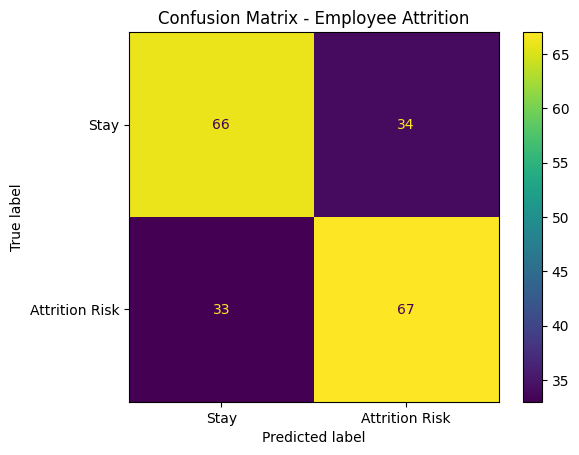

In [33]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Stay", "Attrition Risk"]
)

disp.plot()
plt.title("Confusion Matrix - Employee Attrition")
plt.show()

In [34]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

coefficients.sort_values(
    by="Coefficient",
    ascending=False
)

,Feature,Coefficient
3,job_satisfaction,0.655048
5,promotion_years,0.613644
1,monthly_income,0.583814
0,age,-0.438686
2,years_at_company,-0.446574
4,overtime_hours,-0.619121


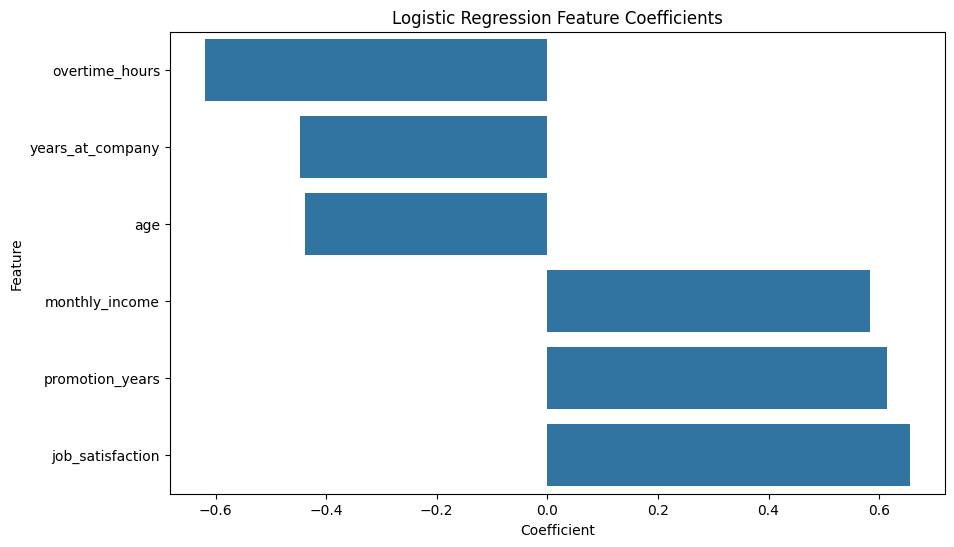

In [35]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=coefficients.sort_values("Coefficient"),
    x="Coefficient",
    y="Feature"
)

plt.title("Logistic Regression Feature Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.show()

In [36]:
coefficients["Effect"] = coefficients["Coefficient"].apply(
    lambda x: "Higher attrition risk" if x > 0 else "Lower attrition risk"
)

coefficients.sort_values(
    by="Coefficient",
    ascending=False
)

,Feature,Coefficient,Effect
3,job_satisfaction,0.655048,Higher attrition risk
5,promotion_years,0.613644,Higher attrition risk
1,monthly_income,0.583814,Higher attrition risk
0,age,-0.438686,Lower attrition risk
2,years_at_company,-0.446574,Lower attrition risk
4,overtime_hours,-0.619121,Lower attrition risk


In [37]:
print(classification_report(
    y_test,
    y_pred,
    target_names=["Stay", "Attrition Risk"]
))

                precision    recall  f1-score   support

          Stay       0.67      0.66      0.66       100
Attrition Risk       0.66      0.67      0.67       100

      accuracy                           0.67       200
     macro avg       0.67      0.67      0.66       200
  weighted avg       0.67      0.67      0.66       200



In [38]:
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

print("True Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives :", tp)

True Negatives : 66
False Positives: 34
False Negatives: 33
True Positives : 67


In [39]:
results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC"
    ],
    "Score": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ]
})

results

,Metric,Score
0,Accuracy,0.665000
1,Precision,0.663366
2,Recall,0.670000
3,F1-score,0.666667
4,ROC-AUC,0.739100


Limitations

The dataset contains only 1,000 employee records.
Only six predictor variables are available.
Employee attrition can depend on many factors that are not included in the dataset.
The model shows associations in the available data and does not prove causation.
Model performance may change when applied to employees from another organization or industry.
The model should be treated as a decision-support tool rather than the sole basis for employee-related decisions.

Possible Improvements

Collect a larger and more diverse dataset.
Include additional factors such as department, job role, work-life balance and performance.
Compare Logistic Regression with other justified classification models.
Tune model hyperparameters.
Address class imbalance if it is significant.
Validate the model on new or external data

Conclusion



This project developed a Logistic Regression model to predict whether an employee is likely to be at risk of attrition within six months. The dataset was inspected for missing values, duplicates, class imbalance and data-quality issues. Appropriate preprocessing and a stratified train-test split were applied to avoid data leakage. The model was evaluated using accuracy, precision, recall, F1-score and ROC-AUC, along with a confusion matrix. The Logistic Regression coefficients were also analyzed to understand the relationship between the input features and predicted attrition risk. The results indicate whether the model can provide useful decision support for identifying employees who may require further attention. However, the model has limitations due to the dataset size and limited number of predictors.